# Distance Doesn't Explain Price
## How airline market power shapes what you pay

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

PALETTE = ["#2166ac", "#4393c3", "#92c5de", "#f4a582", "#d6604d", "#b2182b"]
CARRIER_COLORS = {
    "WN": "#f4a582", "DL": "#2166ac", "AA": "#b2182b",
    "UA": "#4393c3", "AS": "#92c5de", "OO": "#d6604d",
    "MQ": "#762a83", "YX": "#1b7837", "B6": "#fddbc7", "HA": "#e08214",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

DATA = "../assets/data"

scatter  = pd.read_json(f"{DATA}/scatter_distance_fare.json")
r2       = json.load(open(f"{DATA}/r2_comparison.json"))
bubble   = pd.read_json(f"{DATA}/hhi_bubble.json")
mono     = pd.read_json(f"{DATA}/monopoly_routes.json")
airports = pd.read_json(f"{DATA}/airport_carriers.json")
airports = airports[
    (airports.LON > -130) & (airports.LON < -60) &
    (airports.LAT > 24)   & (airports.LAT < 50)
].copy()

## The Assumption We All Make

When buying a plane ticket, most of us assume the price reflects the journey — longer flight, higher fare. It's intuitive. It's also only half right.

Using four quarters of Bureau of Transportation Statistics ticketing data (Q3 2024 – Q2 2025), covering **25 million passenger records** across more than **80,000 routes**, we find that distance explains less than half of what you pay. The rest is something airlines rarely advertise: **market power**.

---

## Static View 1 — Does Distance Predict Fare?

Each dot below is a US airline route. Color shows how concentrated that route is — from competitive (blue) to near-monopoly (red).

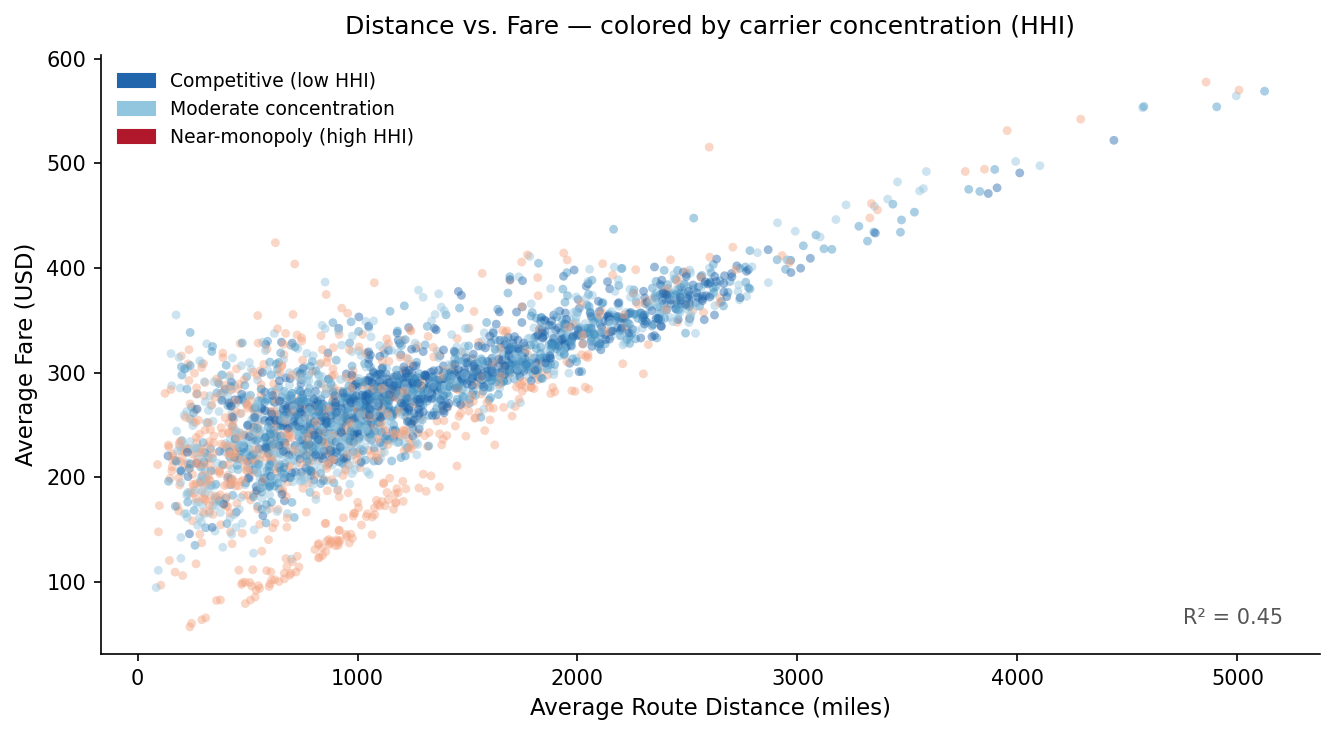

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

q = pd.qcut(scatter["HHI"], 4, labels=False)
colors = [PALETTE[int(v)] for v in q]

sc = ax.scatter(
    scatter["AVG_DISTANCE"], scatter["AVG_FARE"],
    c=colors, alpha=0.45, s=18, linewidths=0
)

ax.set_xlabel("Average Route Distance (miles)", fontsize=11)
ax.set_ylabel("Average Fare (USD)", fontsize=11)
ax.set_title("Distance vs. Fare — colored by carrier concentration (HHI)", fontsize=12, pad=10)

ax.text(0.97, 0.05, "R² = 0.45", transform=ax.transAxes,
        ha="right", fontsize=10, color="#555")

handles = [
    mpatches.Patch(color=PALETTE[0], label="Competitive (low HHI)"),
    mpatches.Patch(color=PALETTE[2], label="Moderate concentration"),
    mpatches.Patch(color=PALETTE[5], label="Near-monopoly (high HHI)"),
]
ax.legend(handles=handles, fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

Distance and fare move together — but the scatter is wide. Many short routes cost more than long ones. Notice the red dots (monopoly routes) clustering above the trend line.

---

## Static View 2 — How Much Does Each Factor Explain?

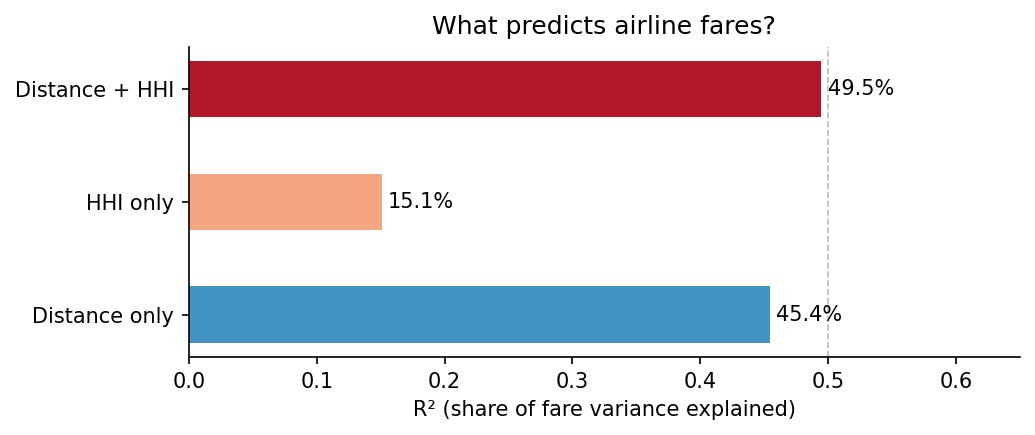

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))

labels = list(r2.keys())
values = list(r2.values())
bar_colors = [PALETTE[1], PALETTE[3], PALETTE[5]]

bars = ax.barh(labels, values, color=bar_colors, height=0.5)

for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", fontsize=10)

ax.set_xlim(0, 0.65)
ax.set_xlabel("R² (share of fare variance explained)", fontsize=10)
ax.set_title("What predicts airline fares?", fontsize=12)
ax.axvline(0.5, color="#bbb", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

Distance alone explains **45%** of fare variance. Adding HHI bumps that to **49%**. HHI alone only explains **15%** — but that's because high-concentration routes also tend to be longer. The key finding: **even after accounting for distance, monopoly routes charge a systematic premium**.

---

## Interactive View 1 — Market Power vs. Fare

Explore every route: the further right a dot, the more one carrier dominates. Hover for details.

In [4]:
bubble["color"] = bubble["TOP_CARRIER"].map(CARRIER_COLORS).fillna("#aaa")
bubble["size"]  = (bubble["TOTAL_PASSENGERS"] / bubble["TOTAL_PASSENGERS"].max() * 30 + 4).clip(4, 34)
bubble["label"] = (
    bubble["ROUTE"] + "<br>Fare: $" + bubble["AVG_FARE"].round(0).astype(int).astype(str) +
    "<br>HHI: " + bubble["HHI"].round(0).astype(int).astype(str) +
    "<br>Top carrier: " + bubble["TOP_CARRIER"] +
    " (" + (bubble["TOP_CARRIER_SHARE"]*100).round(1).astype(str) + "%)" +
    "<br>Passengers: " + bubble["TOTAL_PASSENGERS"].astype(int).apply(lambda x: f"{x:,}")
)

fig1 = go.Figure()
for carrier, grp in bubble.groupby("TOP_CARRIER"):
    fig1.add_trace(go.Scatter(
        x=grp["HHI"], y=grp["AVG_FARE"],
        mode="markers",
        name=carrier,
        marker=dict(
            size=grp["size"],
            color=CARRIER_COLORS.get(carrier, "#aaa"),
            opacity=0.6,
            line=dict(width=0.4, color="white"),
        ),
        hovertemplate=grp["label"] + "<extra>" + carrier + "</extra>",
        text=grp["label"],
    ))

m = np.polyfit(bubble["HHI"], bubble["AVG_FARE"], 1)
x_line = np.linspace(bubble["HHI"].min(), bubble["HHI"].max(), 200)
fig1.add_trace(go.Scatter(
    x=x_line, y=np.polyval(m, x_line),
    mode="lines", name="Trend",
    line=dict(color="#555", dash="dash", width=1.5),
    hoverinfo="skip",
))

fig1.update_layout(
    xaxis_title="HHI (carrier concentration →)",
    yaxis_title="Average Fare (USD)",
    legend_title="Top Carrier",
    height=460,
    margin=dict(l=60, r=20, t=20, b=50),
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig1.update_xaxes(showgrid=True, gridcolor="#eee", tickformat=",")
fig1.update_yaxes(showgrid=True, gridcolor="#eee")
fig1.show()

---

## Interactive View 2 — The Most Expensive Monopoly Routes

These 20 routes combine high fares with near-monopoly control. Hover to explore.

In [5]:
mono_s = mono.sort_values("AVG_FARE", ascending=True).copy()
mono_s["color"]   = mono_s["TOP_CARRIER"].map(CARRIER_COLORS).fillna("#aaa")
mono_s["tooltip"] = (
    mono_s["ROUTE"] + "<br>Fare: $" + mono_s["AVG_FARE"].round(0).astype(int).astype(str) +
    "<br>Carrier: " + mono_s["TOP_CARRIER"] +
    " (" + (mono_s["TOP_CARRIER_SHARE"]*100).round(1).astype(str) + "%)" +
    "<br>HHI: " + mono_s["HHI"].round(0).astype(int).astype(str)
)

fig2 = go.Figure(go.Bar(
    x=mono_s["AVG_FARE"],
    y=mono_s["ROUTE"],
    orientation="h",
    marker_color=mono_s["color"],
    text=mono_s["AVG_FARE"].round(0).astype(int).apply(lambda v: f"${v}"),
    textposition="outside",
    hovertemplate=mono_s["tooltip"] + "<extra></extra>",
))

fig2.update_layout(
    xaxis_title="Average Fare (USD)",
    height=480,
    margin=dict(l=80, r=60, t=20, b=50),
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig2.update_xaxes(showgrid=True, gridcolor="#eee")
fig2.show()

---

## Linked View — Airport Dominance Map

Click any airport to see which carriers control departures from that city.

In [6]:
top50 = airports.nlargest(50, "TOTAL_PAX").reset_index(drop=True)
top50["AIRPORT_HHI"] = top50["carriers"].apply(
    lambda cs: sum(c["share"]**2 for c in cs) * 10_000
)
top50["dot_size"] = (top50["TOTAL_PAX"] / top50["TOTAL_PAX"].max() * 22 + 5).clip(5, 27)

default_idx = top50[top50["AIRPORT"] == "ATL"].index[0] if "ATL" in top50["AIRPORT"].values else 0
default_ap  = top50.iloc[default_idx]["AIRPORT"]

map_trace = go.Scattergeo(
    lon=top50["LON"], lat=top50["LAT"],
    text=top50["AIRPORT"],
    customdata=top50.index,
    mode="markers",
    marker=dict(
        size=top50["dot_size"],
        color=top50["AIRPORT_HHI"],
        colorscale=[[0,"#2166ac"],[0.5,"#f4a582"],[1,"#b2182b"]],
        colorbar=dict(title="HHI", x=1.01, len=0.6),
        line=dict(width=0.5, color="white"),
        opacity=0.8,
    ),
    hovertemplate="<b>%{text}</b><br>HHI: %{marker.color:.0f}<extra></extra>",
    showlegend=False,
)

bar_traces = []
for _, row in top50.iterrows():
    carriers_sorted = sorted(row["carriers"], key=lambda c: -c["share"])
    bar_traces.append(go.Bar(
        x=[c["share"] for c in carriers_sorted],
        y=[c["carrier"] for c in carriers_sorted],
        orientation="h",
        marker_color=[CARRIER_COLORS.get(c["carrier"], "#aaa") for c in carriers_sorted],
        text=[f'{c["share"]*100:.1f}%' for c in carriers_sorted],
        textposition="outside",
        hovertemplate="%{y}: %{x:.1%}<extra></extra>",
        visible=(_ == default_idx),
        showlegend=False,
        xaxis="x2", yaxis="y2",
    ))

buttons = []
for i, row in top50.iterrows():
    vis = [True] + [j == i for j in top50.index]
    buttons.append(dict(
        method="update",
        label=row["AIRPORT"],
        args=[
            {"visible": vis},
            {"annotations": [dict(
                text=f"Carrier share at {row['AIRPORT']}",
                x=0.5, y=0.42, xref="paper", yref="paper",
                showarrow=False, font=dict(size=12),
            )]}
        ],
    ))

fig3 = go.Figure(data=[map_trace] + bar_traces)

fig3.update_layout(
    geo=dict(
        scope="usa",
        projection_type="albers usa",
        showland=True, landcolor="#f5f5f5",
        showlakes=True, lakecolor="#d0e8f5",
        showcountries=False,
        showsubunits=True, subunitcolor="#ddd",
        domain=dict(x=[0,1], y=[0.45,1]),
    ),
    xaxis2=dict(domain=[0.05,0.95], anchor="y2", tickformat=".0%",
                title="Passenger share", showgrid=True, gridcolor="#eee"),
    yaxis2=dict(domain=[0,0.38], anchor="x2"),
    updatemenus=[dict(
        type="dropdown",
        buttons=buttons,
        x=0.01, xanchor="left",
        y=0.41, yanchor="top",
        bgcolor="white",
        bordercolor="#ccc",
    )],
    annotations=[dict(
        text=f"Carrier share at {default_ap}",
        x=0.5, y=0.42, xref="paper", yref="paper",
        showarrow=False, font=dict(size=12),
    )],
    height=720,
    margin=dict(l=20, r=60, t=20, b=20),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig3.show()

---

## Infographic — What Explains Your Ticket Price?

In [7]:
from IPython.display import HTML

HTML("""
<div style="display:flex; gap:16px; flex-wrap:wrap; margin:2rem 0; font-family:sans-serif;">

  <div style="flex:1; min-width:160px; background:#2166ac; color:white; border-radius:10px; padding:24px 20px; text-align:center;">
    <div style="font-size:2.8rem; font-weight:700;">45%</div>
    <div style="font-size:1rem; margin-top:6px;">Distance</div>
    <div style="font-size:0.8rem; margin-top:8px; opacity:0.85;">Longer routes cost more — but not as much as you'd expect</div>
  </div>

  <div style="flex:1; min-width:160px; background:#d6604d; color:white; border-radius:10px; padding:24px 20px; text-align:center;">
    <div style="font-size:2.8rem; font-weight:700;">+4%</div>
    <div style="font-size:1rem; margin-top:6px;">Market Power</div>
    <div style="font-size:0.8rem; margin-top:8px; opacity:0.85;">Carrier concentration adds a premium on top of distance</div>
  </div>

  <div style="flex:1; min-width:160px; background:#555; color:white; border-radius:10px; padding:24px 20px; text-align:center;">
    <div style="font-size:2.8rem; font-weight:700;">51%</div>
    <div style="font-size:1rem; margin-top:6px;">Unexplained</div>
    <div style="font-size:0.8rem; margin-top:8px; opacity:0.85;">Seasonality, seat class, booking timing, fuel costs…</div>
  </div>

</div>

<div style="display:flex; gap:16px; flex-wrap:wrap; margin:1rem 0 2rem; font-family:sans-serif;">

  <div style="flex:1; min-width:200px; background:#f0f4f8; border-left:4px solid #2166ac; border-radius:6px; padding:16px 18px;">
    <div style="font-size:0.75rem; color:#666; text-transform:uppercase; letter-spacing:0.05em;">Most competitive route</div>
    <div style="font-size:1.3rem; font-weight:600; margin-top:4px;">ATL &#8596; ORD</div>
    <div style="font-size:0.9rem; color:#444;">6 carriers · avg $178</div>
  </div>

  <div style="flex:1; min-width:200px; background:#f0f4f8; border-left:4px solid #b2182b; border-radius:6px; padding:16px 18px;">
    <div style="font-size:0.75rem; color:#666; text-transform:uppercase; letter-spacing:0.05em;">Worst monopoly route</div>
    <div style="font-size:1.3rem; font-weight:600; margin-top:4px;">EWR &#8596; HNL</div>
    <div style="font-size:0.9rem; color:#444;">United 88% share · avg $570</div>
  </div>

</div>
""")

---

## Data & Methods

Data: BTS DB1B Market, Q3 2024 – Q2 2025. Fares filtered to remove outliers (IQR method, price-per-mile floor). Carrier concentration measured using the Herfindahl-Hirschman Index (HHI) computed from passenger share per route. Regression on log-transformed route-level average fares. Full methodology in the Technical Appendix (`../technical-details/story/main.ipynb`).